# Sparkov Fraud EDA

This notebook reads the privacy-safe portfolio Parquet, or the sanitized CI fixture when full data is unavailable, and reproduces the main imbalance and segment evidence. Sparkov is synthetic and is not bank production traffic.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
portfolio = ROOT / "data/processed/transactions_portfolio.parquet"
source = portfolio if portfolio.exists() else ROOT / "data/processed/transactions_ci.parquet"
data = pl.read_parquet(source)
{"source": source.name, "shape": data.shape}

{'source': 'transactions_portfolio.parquet', 'shape': (1852394, 13)}

In [2]:
summary = data.select(
    pl.len().alias("transactions"),
    pl.col("is_fraud").sum().alias("fraud"),
    pl.col("is_fraud").mean().alias("fraud_rate"),
    pl.col("amount").sum().alias("total_amount"),
)
summary

transactions,fraud,fraud_rate,total_amount
u32,i64,f64,f64
1852394,9651,0.00521,1.2979e8


In [3]:
by_category = (
    data.group_by("merchant_category")
    .agg(pl.len().alias("transactions"), pl.col("is_fraud").mean().alias("fraud_rate"))
    .sort("fraud_rate", descending=True)
)
by_category

merchant_category,transactions,fraud_rate
str,u32,f64
"""shopping_net""",139322,0.015927
"""misc_net""",90654,0.013039
"""grocery_pos""",176191,0.012645
"""shopping_pos""",166463,0.006344
"""gas_transport""",188029,0.004106
…,…,…
"""entertainment""",134118,0.002177
"""kids_pets""",161727,0.00188
"""food_dining""",130729,0.001568


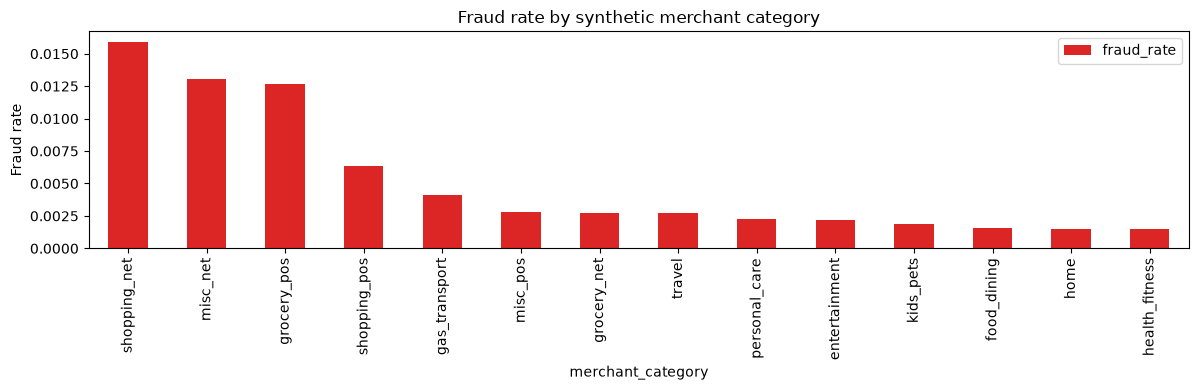

In [4]:
plot = by_category.to_pandas().plot.bar(
    x="merchant_category",
    y="fraud_rate",
    figsize=(12, 4),
    color="#dc2626",
    title="Fraud rate by synthetic merchant category",
)
plot.set_ylabel("Fraud rate")
plt.tight_layout()

## Interpretation

Accuracy is misleading at this class ratio. Merchant category and amount patterns are generator-specific, so the production design emphasizes chronological validation, calibrated probability, capacity-aware thresholds, delayed labels, and drift monitoring rather than treating this EDA as real bank behavior.